In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"
df = pd.read_csv(url, sep=';')
X = df.drop('quality', axis=1)
y = df['quality']

liczba_cech_oryg = X.shape[1]
print(f"Oryginalny wymiar zbioru cech X: {X.shape}")

Oryginalny wymiar zbioru cech X: (4898, 11)


 # Zadanie 1

Bazując na przykładowym kodzie implementacji PCA dla zbioru iris z wykładu, przygotuj implementację dla zbioru numer 1 (white wine powyżej) redukując liczbę cech tego zbioru o 2. Ile wariancji originalnego zbioru wyjaśnia nowy, zredukowany zbiór?

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_zad1 = PCA(n_components=liczba_cech_oryg - 2)
X_pca_zad1 = pca_zad1.fit_transform(X_scaled)
wariancja_zad1 = sum(pca_zad1.explained_variance_ratio_) * 100

print(f"Liczba cech po redukcji o 2: {pca_zad1.n_components_}")
print(f"Zredukowany zbior wyjaśnia {wariancja_zad1:.2f}% wariancji oryginalnego zbioru.")

Liczba cech po redukcji o 2: 9
Zredukowany zbior wyjaśnia 97.18% wariancji oryginalnego zbioru.


# Zadanie 2

Sprawdź w dokumentacji pakietu (link powyżej) w jaki sposób dobierając wartość parametru n_components można ustawić próg wariancji, poniżej którego nie chcemy zejść przygotowując nowy, zredukowany zbiór danych. Ustaw ten próg na 95% i sprawdź ile cech pozostało w finalnym zbiorze danych.

In [5]:
pca_zad2 = PCA(n_components=0.95)
X_pca_zad2 = pca_zad2.fit_transform(X_scaled)
wariancja_zad2 = sum(pca_zad2.explained_variance_ratio_) * 100

print(f"Liczba cech niezbedna do zachowania 95% wariancji: {pca_zad2.n_components_}")
print(f"Faktyczna wyjaśniona wariancja : {wariancja_zad2:.2f}%")

Liczba cech niezbedna do zachowania 95% wariancji: 9
Faktyczna wyjaśniona wariancja : 97.18%


# Zadanie 3

Przygotuj kod, którym sprawdzisz teraz jaki wpływ na model klasyfikacji ma zastosowana redukcja wymiarowości w zadaniu 1 oraz 2. Wykorzystaj kod z labu poprzedniego (czyli sekcja 1.1 w wykładzie 6 z KNNClassifier).

Ogólny pipeline:
- wczytanie danych,
- skalowanie (trzeba przed użyciema PCA) - pamiętaj o podziale danych i ochronie przed ich wyciekiem,
- redukcja wymiarowości (eksperyment 1 - o 2 cechy, eksperyment 2 - z progiem wariancji),
-   trening modelu, walidacja i zebranie metryk
Mile widziane:
1. Podobnie jak przy wcześniejszych eksperymentach, warto je powtórzyć na różnych podzbiorach danych (losowy podział). Zastanów się jak i gdzie wpleść pętlę, w której można określić liczbę eksperymentów i zbierać wyniki dla każdego z nich.
2. Wygenerowanie wykresów pudełkowych dla wielu wyników eksperymentów może ukazać charakterystykę każdego podejścia, np. mniejszy rozrzut wyników, czyli większą stabilność modelu (węższy przedział ufności co do wartości oczekiwanej danej metryki modelu).

Trwa wielokrotne trenowanie modeli...

Średnie wyniki dokładności (Accuracy) z 30 eksperymentów:
Brak PCA (11 cech)       0.5531
PCA -2 cechy (9 cech)    0.5582
PCA próg 95% (8 cech)    0.5582
dtype: float64


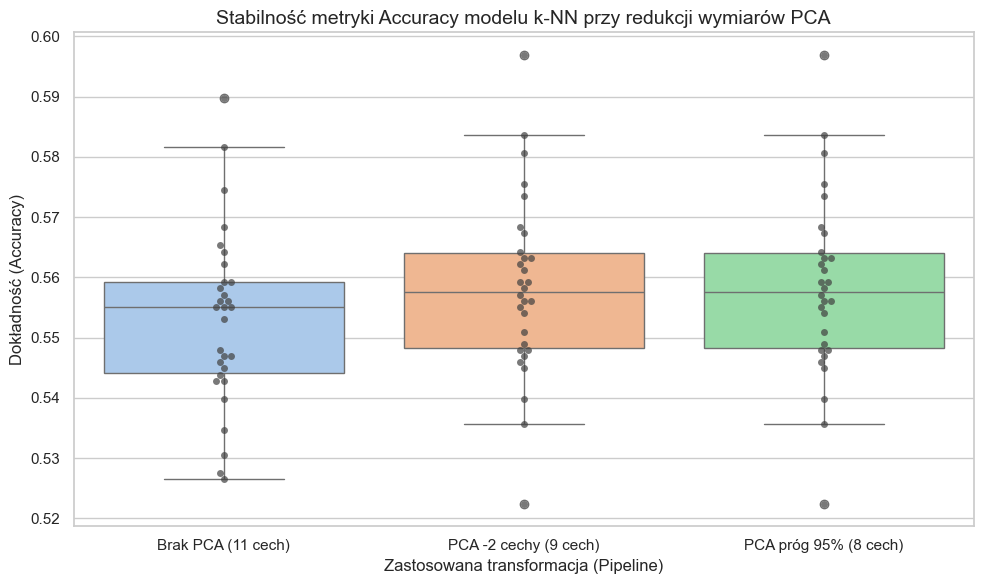

In [6]:
print("Trwa wielokrotne trenowanie modeli...")

n_eksperymentow = 30
wyniki = {
    'Brak PCA (11 cech)': [],
    'PCA -2 cechy (9 cech)': [],
    'PCA próg 95% (8 cech)': []
}

for i in range(n_eksperymentow):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)

    pipe_base = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ])
    pipe_base.fit(X_train, y_train)
    wyniki['Brak PCA (11 cech)'].append(accuracy_score(y_test, pipe_base.predict(X_test)))

    pipe_pca_1 = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=liczba_cech_oryg - 2)),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ])
    pipe_pca_1.fit(X_train, y_train)
    wyniki['PCA -2 cechy (9 cech)'].append(accuracy_score(y_test, pipe_pca_1.predict(X_test)))

    pipe_pca_2 = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95)),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ])
    pipe_pca_2.fit(X_train, y_train)
    wyniki['PCA próg 95% (8 cech)'].append(accuracy_score(y_test, pipe_pca_2.predict(X_test)))

df_wyniki = pd.DataFrame(wyniki)
print("\nŚrednie wyniki dokładności (Accuracy) z 30 eksperymentów:")
print(df_wyniki.mean().round(4))

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.boxplot(data=df_wyniki, palette="pastel")
sns.swarmplot(data=df_wyniki, color=".25", size=5, alpha=0.7, ax=ax) # Naniesienie pojedynczych punktów

plt.title('Stabilność metryki Accuracy modelu k-NN przy redukcji wymiarów PCA', fontsize=14)
plt.ylabel('Dokładność (Accuracy)', fontsize=12)
plt.xlabel('Zastosowana transformacja (Pipeline)', fontsize=12)
plt.tight_layout()
plt.show()